
# Regression Diagnostics

## Trust, but Verify

In the previous session, we trained a Linear Regression model and checked the $R^2$ score. However, a high $R^2$ does not necessarily mean the model is valid.

Linear Regression relies on specific assumptions (Linearity, Independence, Normality, Homoscedasticity). If these are violated, your predictions—and especially your confidence intervals—can be completely wrong. ****Regression Diagnostics**** is the art of checking these assumptions, primarily by analyzing the ****Residuals**** (the errors).

## Key Diagnostic Checks

| Assumption           | What it means                                 | How to Diagnose                                                                                                               | Potential Fix                                                        |
|-------------------- |--------------------------------------------- |----------------------------------------------------------------------------------------------------------------------------- |-------------------------------------------------------------------- |
| **Linearity**        | The relationship is actually a straight line. | **Residual Plot**: Residuals should be randomly scattered around 0. If you see a curve (U-shape), the assumption is violated. | Polynomial features, Non-linear models.                              |
| **Homoscedasticity** | The error variance is constant.               | **Scale-Location Plot**: If the residuals "fan out" (get wider) as prediction increases, you have heteroscedasticity.         | Log-transform the target ($y$), or use Weighted Least Squares (WLS). |
| **Normality**        | The errors follow a Normal Distribution.      | **Q-Q Plot**: Points should fall on the diagonal line.                                                                        | Log-transform, remove outliers.                                      |
| **Independence**     | Errors are not correlated with each other.    | **Autocorrelation Plot**: Crucial for time-series data.                                                                       | Time-series models (ARIMA).                                          |

## Practical Demonstration

We will generate a dataset that **looks** linear but violates the assumption of **Homoscedasticity** (constant variance), a very common real-world issue (e.g., as income grows, the variance in spending grows).

### Generate "Bad" Data (Heteroscedasticity)

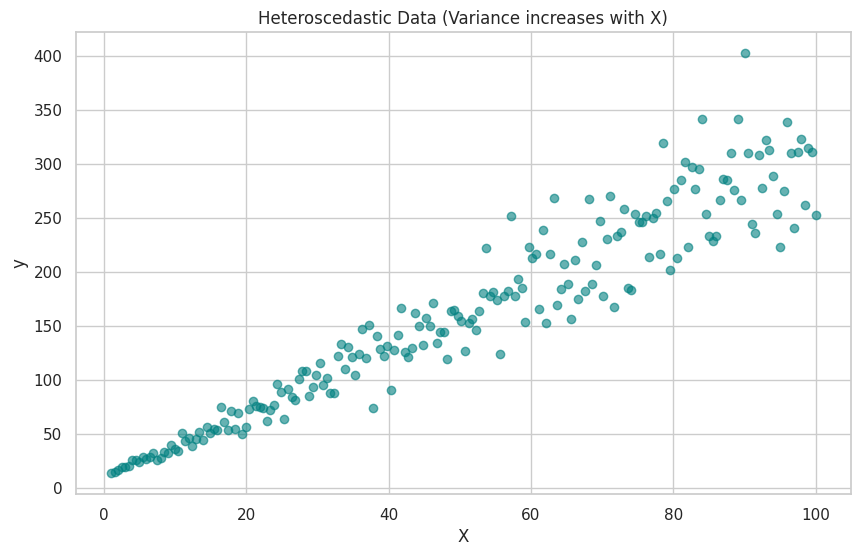

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate X
X = np.linspace(1, 100, 200).reshape(-1, 1)

# Generate y: The noise increases as X increases
# Notice the noise term: np.random.randn() * X
y = 3 * X + 10 + (np.random.randn(200, 1) * (X * 0.5))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='teal')
plt.title("Heteroscedastic Data (Variance increases with X)")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Train and Evaluate (The Trap)

We fit a standard Linear Regression.

In [2]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"R² Score: {r2_score(y, y_pred):.4f}")

R² Score: 0.9140


**Observation**: The $R^2$ is likely high (around 0.8-0.9). A beginner would stop here and declare success.

### Diagnostic: Residual Plot

We plot the **Residuals** ($y_{true} - y_{pred}$) against the **Predicted Values**.

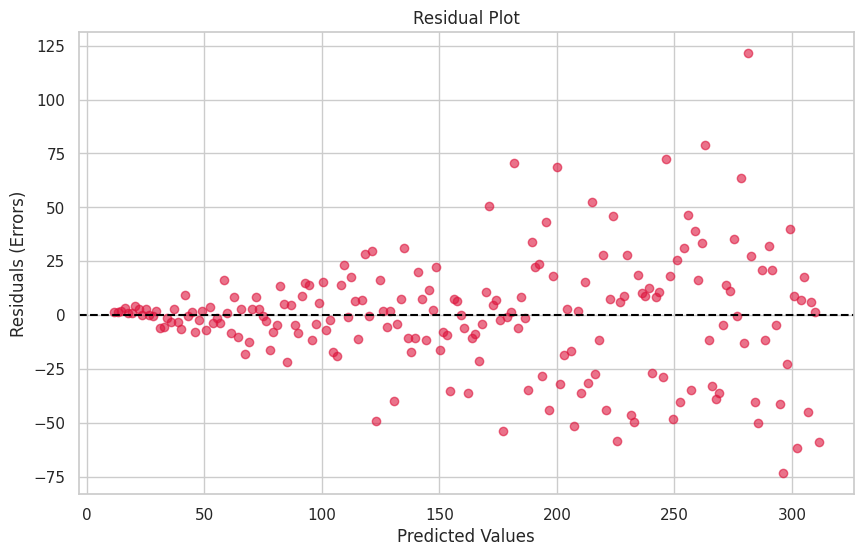

In [3]:
residuals = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='crimson')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.show()

**Diagnosis**: Notice the **Funnel Shape**? The errors are small on the left and huge on the right. This confirms **Heteroscedasticity**. The model is untrustworthy for high values of $X$.

### Diagnostic: Scale-Location Plot (Homoscedasticity)

The **Scale-Location Plot** (also called Spread-Location) is specifically designed to detect heteroscedasticity. It plots $\sqrt{|\text{standardized residuals}|}$ against fitted values. If homoscedasticity holds, the points should form a horizontal band with no trend.

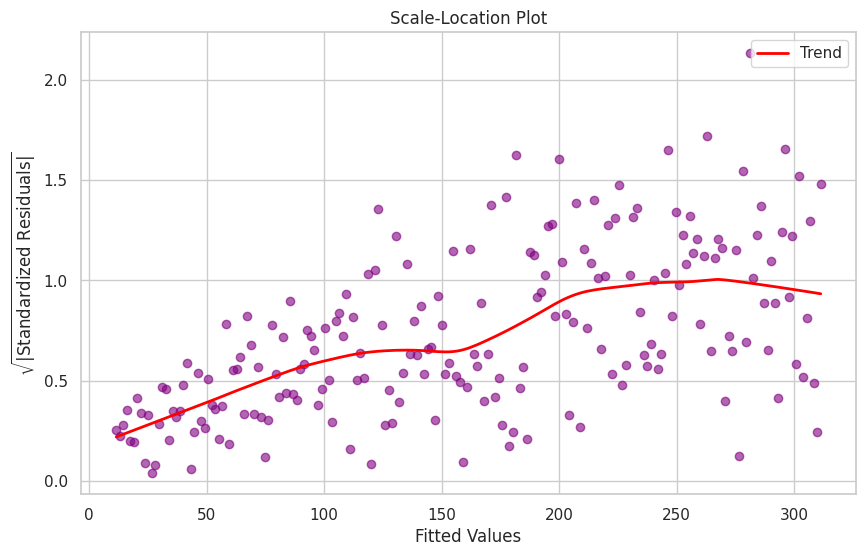

In [4]:
# Standardize residuals (subtract mean, divide by std)
residuals_standardized = (residuals - residuals.mean()) / residuals.std()

# Scale-Location: sqrt of absolute standardized residuals
sqrt_abs_resid = np.sqrt(np.abs(residuals_standardized))

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, sqrt_abs_resid, alpha=0.6, color='purple')

# Add a lowess smoothing line to show the trend
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(sqrt_abs_resid.ravel(), y_pred.ravel(), frac=0.3)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2, label='Trend')

plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel(r"$\sqrt{|\mathrm{Standardized\ Residuals}|}$")
plt.legend()
plt.show()

**Diagnosis**: The red trend line should be roughly horizontal. An upward slope (as seen here) confirms \*Heteroscedasticity\*—the spread of residuals increases with fitted values.

### Diagnostic: Q-Q Plot (Normality)

We check if the errors are normally distributed using a Quantile-Quantile (Q-Q) plot.

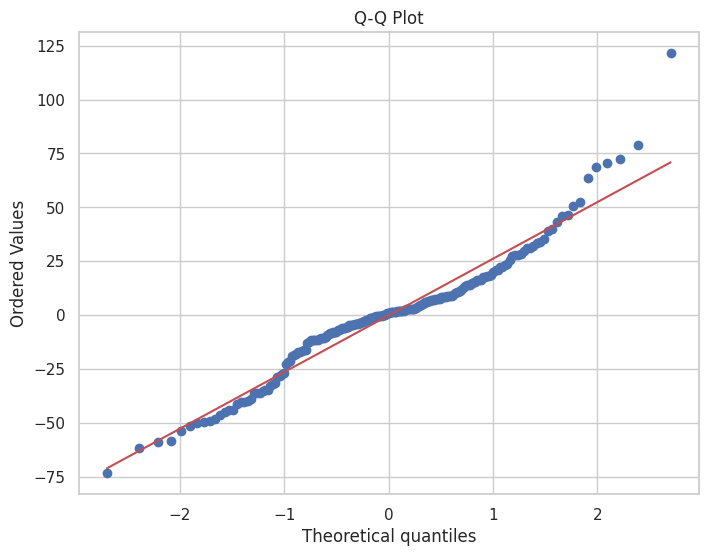

In [5]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals.ravel(), dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

**Diagnosis**: If the blue dots deviate significantly from the red line (tails curving off), the errors are not normal.

### Diagnostic: Autocorrelation (Independence)

For time-series data, errors from one observation may be correlated with errors from previous observations. This violates the **Independence** assumption and makes standard errors unreliable.

We generate synthetic "time-series" data where the error at time $t$ depends on the error at time $t-1$.

In [6]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)

# Generate time-series X (e.g., months 1-100)
X_time = np.arange(1, 101).reshape(-1, 1)

# Generate autocorrelated errors: e[t] = 0.8 * e[t-1] + noise
errors = np.zeros(100)
for t in range(1, 100):
    errors[t] = 0.8 * errors[t - 1] + np.random.normal(0, 5)

# True relationship: y = 2*X + autocorrelated_error
y_time = 2 * X_time.ravel() + 50 + errors

# Fit model
model_time = LinearRegression()
model_time.fit(X_time, y_time)
y_pred_time = model_time.predict(X_time)
residuals_time = y_time - y_pred_time

#### Durbin-Watson Test

The Durbin-Watson statistic tests for first-order autocorrelation. Values range from 0 to 4:

-   **~2**: No autocorrelation (good)
-   **<1.5**: Positive autocorrelation (errors follow each other)
-   **>2.5**: Negative autocorrelation (errors alternate)

In [7]:
dw_stat = durbin_watson(residuals_time)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

if dw_stat < 1.5:
    print("⚠️  Strong positive autocorrelation detected!")
elif dw_stat > 2.5:
    print("⚠️  Strong negative autocorrelation detected!")
else:
    print("✓ No significant autocorrelation.")

Durbin-Watson statistic: 0.437
⚠️  Strong positive autocorrelation detected!


#### Autocorrelation Function (ACF) Plot

The ACF plot shows correlation between residuals at different lags. Significant spikes beyond the confidence band (blue shaded area) indicate autocorrelation.

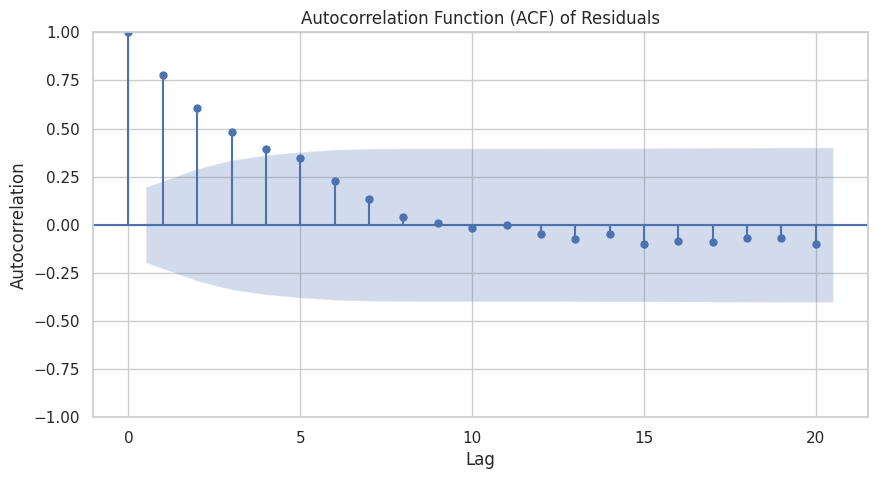

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals_time, lags=20, ax=ax)
ax.set_title("Autocorrelation Function (ACF) of Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.show()

**Diagnosis**: If you see significant spikes at lag 1, 2, etc., your residuals are not independent. Standard OLS confidence intervals and p-values will be wrong. Consider using time-series models (ARIMA) or Newey-West standard errors.

## Exercises

Now, you will diagnose a different problem: **Non-Linearity**.

### Generate Non-Linear Data

Generate data following a parabola: $y = x^2 + \text{noise}$.

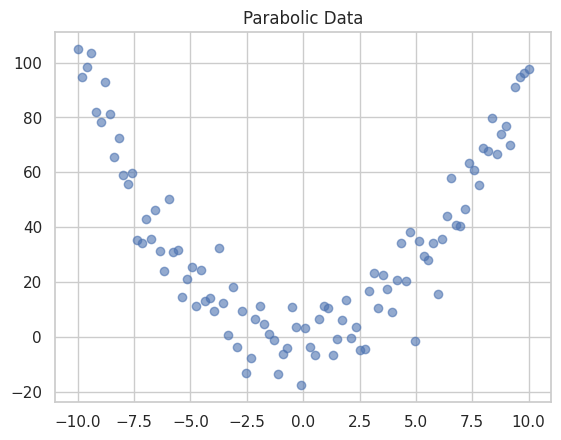

In [9]:
np.random.seed(42)
X_poly = np.linspace(-10, 10, 100).reshape(-1, 1)
y_poly = X_poly**2 + np.random.normal(0, 10, (100, 1))

plt.scatter(X_poly, y_poly, alpha=0.6)
plt.title("Parabolic Data")
plt.show()

### Fit Linear Model & Plot Residuals

Fit a `LinearRegression` model. Then, plot the residuals vs. predictions.

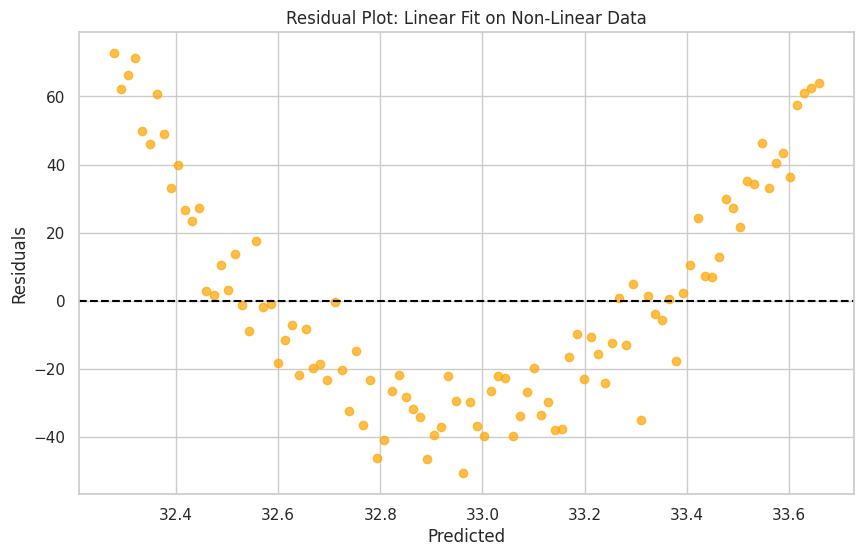

In [10]:
# Fit
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_poly)
y_pred_poly = lr_poly.predict(X_poly)

# Residuals
res_poly = y_poly - y_pred_poly

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_poly, res_poly, color='orange', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot: Linear Fit on Non-Linear Data")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

**Question**: What shape do you see in the residual plot?

**Answer**: You should see a clear ****U-shape**** (Parabola). This pattern screams "You need a non-linear model" (which sets the stage for your future module on **Nonlinearities**).

### Outlier Detection (Cook's Distance)

Influential points can skew the model. We can detect them using **Cook's Distance**. **Note**: We use statsmodels here as it has built-in diagnostic tools.

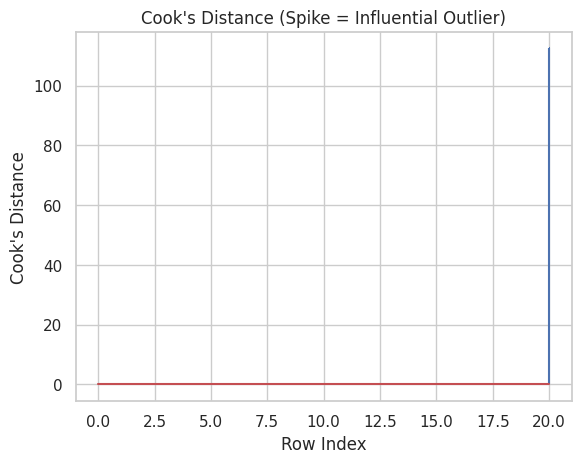

In [11]:
# Generate data with one massive outlier
X_out = np.append(X[:20], [[50]], axis=0) # Add outlier X
y_out = np.append(y[:20], [[500]], axis=0) # Add outlier y

import statsmodels.api as sm

# Fit OLS (Ordinary Least Squares)
X_aug = sm.add_constant(X_out)
model_sm = sm.OLS(y_out, X_aug).fit()

# Calculate Cook's Distance
influence = model_sm.get_influence()
(c, p) = influence.cooks_distance

plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.title("Cook's Distance (Spike = Influential Outlier)")
plt.xlabel("Row Index")
plt.ylabel("Cook's Distance")
plt.show()

#### Interpreting Cook's Distance

Common thresholds to identify influential points:

-   **D > 4/n**: Point may be influential (n = number of observations)
-   **D > 1**: Point is highly influential (conservative rule)

Threshold (4/n): 0.1905
Influential points (index): [20]
Their Cook's Distance values: [112.39524325]


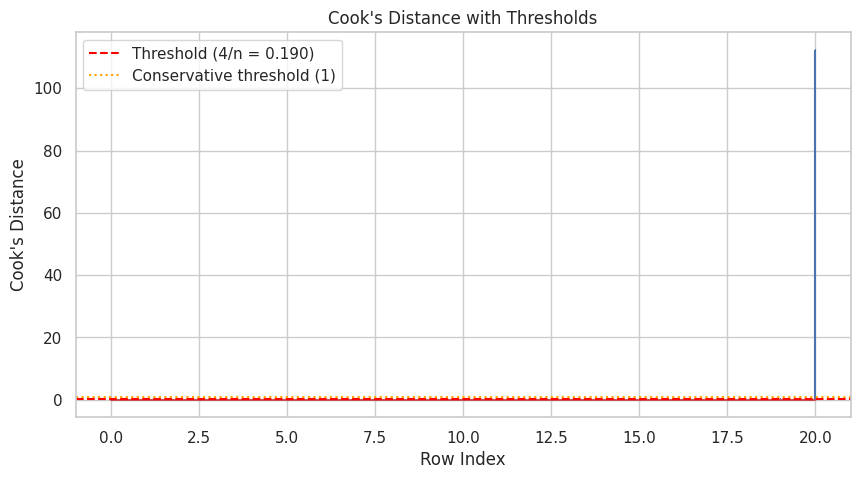

In [12]:
n = len(c)
threshold = 4 / n

# Find influential points
influential_idx = np.where(c > threshold)[0]

print(f"Threshold (4/n): {threshold:.4f}")
print(f"Influential points (index): {influential_idx}")
print(f"Their Cook's Distance values: {c[influential_idx]}")

# Visualize with threshold line
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.3f})')
plt.axhline(1, color='orange', linestyle=':', label='Conservative threshold (1)')
plt.title("Cook's Distance with Thresholds")
plt.xlabel("Row Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

**What to do with influential points?**

1.  **Investigate**: Is it a data entry error? Correct it.
2.  **Domain knowledge**: Is this observation genuinely unusual but valid?
3.  **Sensitivity analysis**: Fit the model with and without the point. If coefficients change drastically, report both results.
4.  **Robust regression**: Use methods like RANSAC or Huber regression (not covered in this training) that down-weight outliers.

## Summary

1.  **Don't trust $R^2$ alone**. It hides many sins.
2.  **Residual Plots** are your best friend.
    -   Random scatter = Good.
    -   Funnel shape = Heteroscedasticity (Needs Log transform or WLS).
    -   U-shape = Non-linearity (Needs Polynomials).
3.  **Q-Q Plots** check for Normality.
4.  **Durbin-Watson & ACF Plots** check for Independence (autocorrelation). Critical for time-series data.
5.  **Cook's Distance** identifies influential outliers. Use threshold $D > 4/n$ to flag suspects.